In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv(
    r"C:\Users\saran\guvi project\cart2insights\data\cleaned\orders_cleaned.csv"
)

order_items = pd.read_csv(
    r"C:\Users\saran\guvi project\cart2insights\data\cleaned\order_items_cleaned.csv"
)

products = pd.read_csv(
    r"C:\Users\saran\guvi project\cart2insights\data\cleaned\products_cleaned.csv"
)

category_translation = pd.read_csv(
    r"C:\Users\saran\guvi project\cart2insights\data\cleaned\product_category_name_translation_cleaned.csv"
)

sellers = pd.read_csv(
    r"C:\Users\saran\guvi project\cart2insights\data\cleaned\sellers_cleaned.csv"
)

In [5]:
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Categories:", category_translation.shape)
print("Sellers:", sellers.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Categories: (71, 2)
Sellers: (3095, 4)


In [6]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [7]:
sales_data = orders.merge(
    order_items[['order_id', 'price', 'freight_value']],
    on='order_id',
    how='inner'
)

print(sales_data.shape)

(112650, 10)


In [8]:
sales_data['month'] = sales_data['order_purchase_timestamp'].dt.to_period('M')

In [9]:
monthly_revenue = (
    sales_data.groupby('month')['price']
    .sum()
    .reset_index()
)

monthly_revenue['month'] = monthly_revenue['month'].astype(str)

monthly_revenue['price'] = monthly_revenue['price'].round(2)

monthly_revenue.head()

,month,price
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02


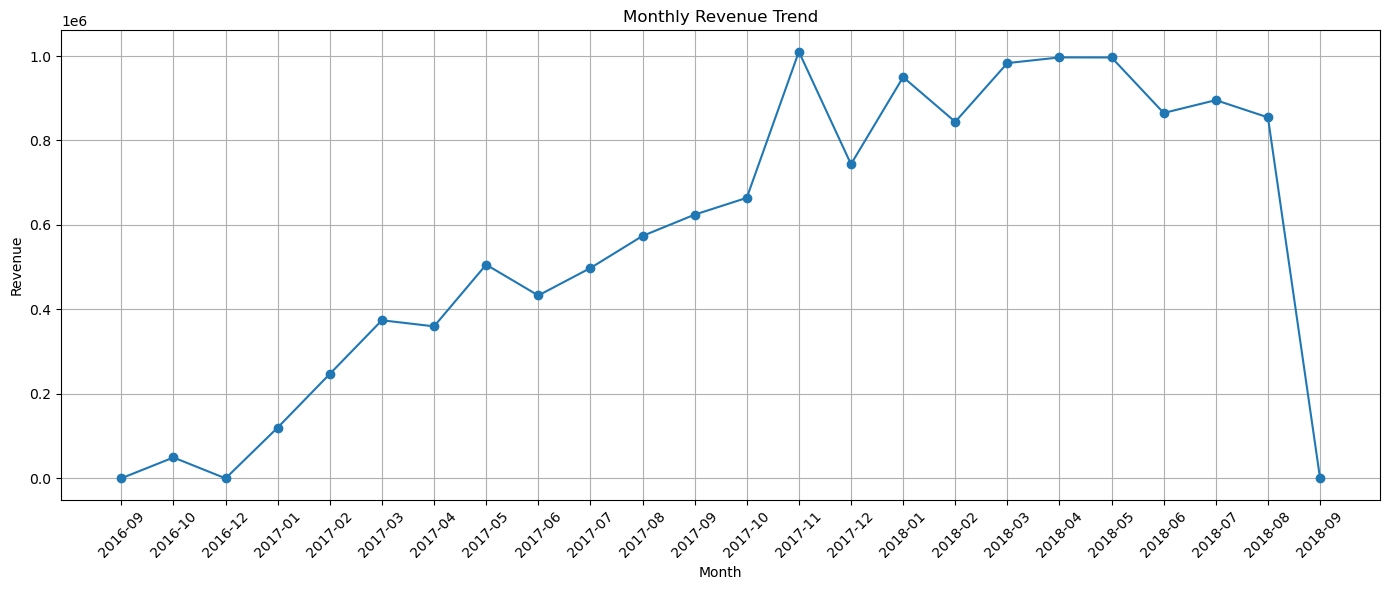

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['price'],
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
category_sales = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

In [14]:
category_sales = category_sales.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

In [15]:
category_sales['category'] = (
    category_sales['product_category_name_english']
    .fillna(category_sales['product_category_name'])
    .fillna('unknown')
)

In [16]:
category_revenue = (
    category_sales
    .groupby('category')['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue['price'] = category_revenue['price'].round(2)

category_revenue.head(10)

,category,price
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


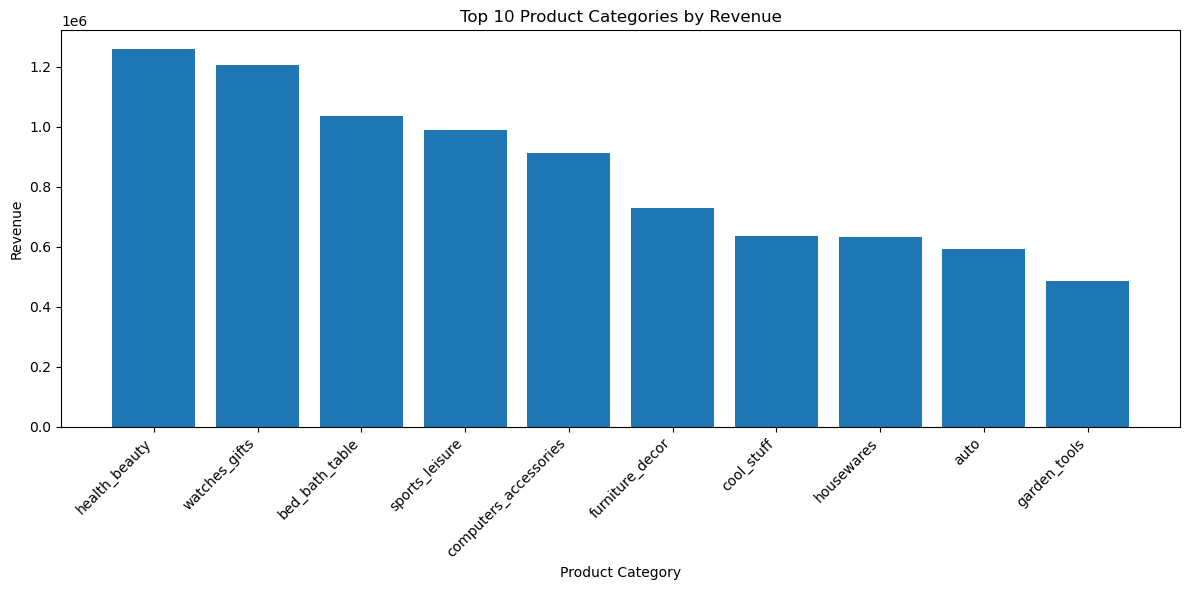

In [17]:
plt.figure(figsize=(12, 6))

plt.bar(
    category_revenue['category'].head(10),
    category_revenue['price'].head(10)
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Revenue')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [18]:
product_revenue = (
    order_items
    .groupby('product_id')
    .agg(
        total_revenue=('price', 'sum'),
        total_units=('product_id', 'count')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

product_revenue.head(10)

,product_id,total_revenue,total_units
0,bb50f2e236e5eea0100680137654686c,63885.00,195
1,6cdd53843498f92890544667809f1595,54730.20,156
2,d6160fb7873f184099d9bc95e30376af,48899.34,35
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,343
4,99a4788cb24856965c36a24e339b6058,43025.56,488
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60,274
6,25c38557cf793876c5abdd5931f922db,38907.32,38
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63
8,53b36df67ebb7c41585e8d54d6772e08,37683.42,323
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,527


In [19]:
product_revenue = product_revenue.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

product_revenue.head(10)

,product_id,total_revenue,total_units,product_category_name
0,bb50f2e236e5eea0100680137654686c,63885.00,195,beleza_saude
1,6cdd53843498f92890544667809f1595,54730.20,156,beleza_saude
2,d6160fb7873f184099d9bc95e30376af,48899.34,35,pcs
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,343,informatica_acessorios
4,99a4788cb24856965c36a24e339b6058,43025.56,488,cama_mesa_banho
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60,274,informatica_acessorios
6,25c38557cf793876c5abdd5931f922db,38907.32,38,bebes
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63,cool_stuff
8,53b36df67ebb7c41585e8d54d6772e08,37683.42,323,relogios_presentes
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,527,moveis_decoracao


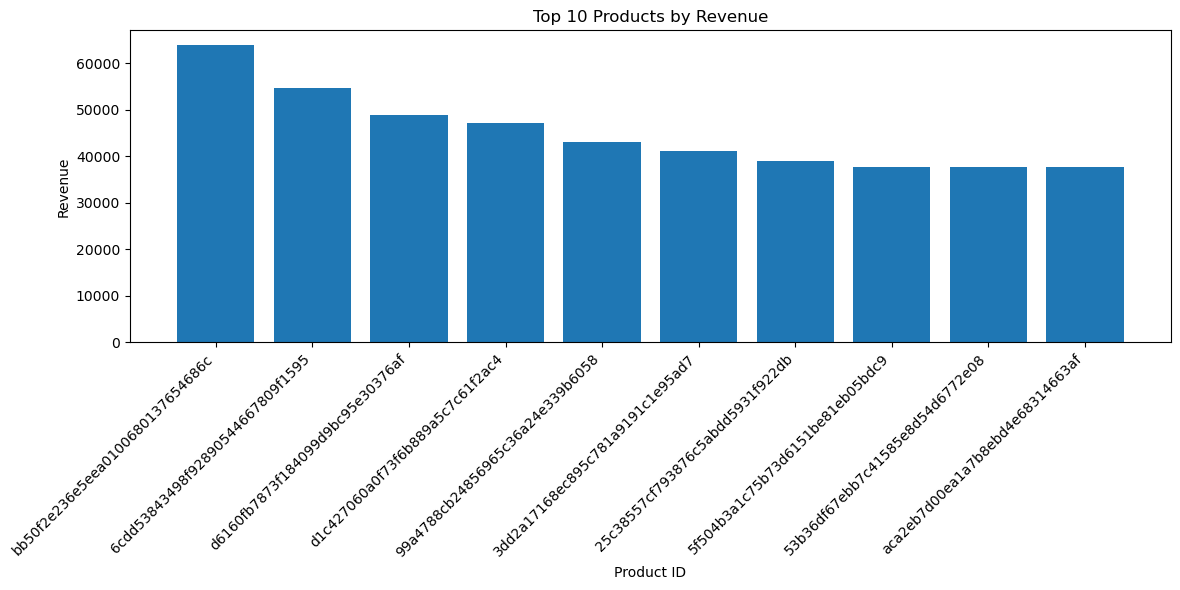

In [20]:
plt.figure(figsize=(12, 6))

plt.bar(
    product_revenue['product_id'].head(10),
    product_revenue['total_revenue'].head(10)
)

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product ID')
plt.ylabel('Revenue')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [21]:
top_products = product_revenue.head(10).copy()

top_products['total_revenue'] = top_products['total_revenue'].round(2)

top_products

,product_id,total_revenue,total_units,product_category_name
0,bb50f2e236e5eea0100680137654686c,63885.00,195,beleza_saude
1,6cdd53843498f92890544667809f1595,54730.20,156,beleza_saude
2,d6160fb7873f184099d9bc95e30376af,48899.34,35,pcs
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,343,informatica_acessorios
4,99a4788cb24856965c36a24e339b6058,43025.56,488,cama_mesa_banho
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60,274,informatica_acessorios
6,25c38557cf793876c5abdd5931f922db,38907.32,38,bebes
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63,cool_stuff
8,53b36df67ebb7c41585e8d54d6772e08,37683.42,323,relogios_presentes
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,527,moveis_decoracao


In [22]:
seller_revenue = (
    order_items
    .groupby('seller_id')
    .agg(
        total_revenue=('price', 'sum'),
        total_items=('order_id', 'count'),
        total_orders=('order_id', 'nunique')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

seller_revenue.head(10)

,seller_id,total_revenue,total_items,total_orders
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1156,1132
1,53243585a1d6dc2643021fd1853d8905,222776.05,410,358
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1987,1806
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,586,585
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,1364,982
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,340,336
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1551,1314
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1171,1160
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,1428,915
9,955fee9216a65b617aa5c0531780ce60,135171.70,1499,1287


In [23]:
top_sellers = seller_revenue.head(10).copy()

top_sellers['total_revenue'] = top_sellers['total_revenue'].round(2)

top_sellers

,seller_id,total_revenue,total_items,total_orders
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1156,1132
1,53243585a1d6dc2643021fd1853d8905,222776.05,410,358
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1987,1806
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,586,585
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,1364,982
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,340,336
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1551,1314
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1171,1160
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,1428,915
9,955fee9216a65b617aa5c0531780ce60,135171.70,1499,1287


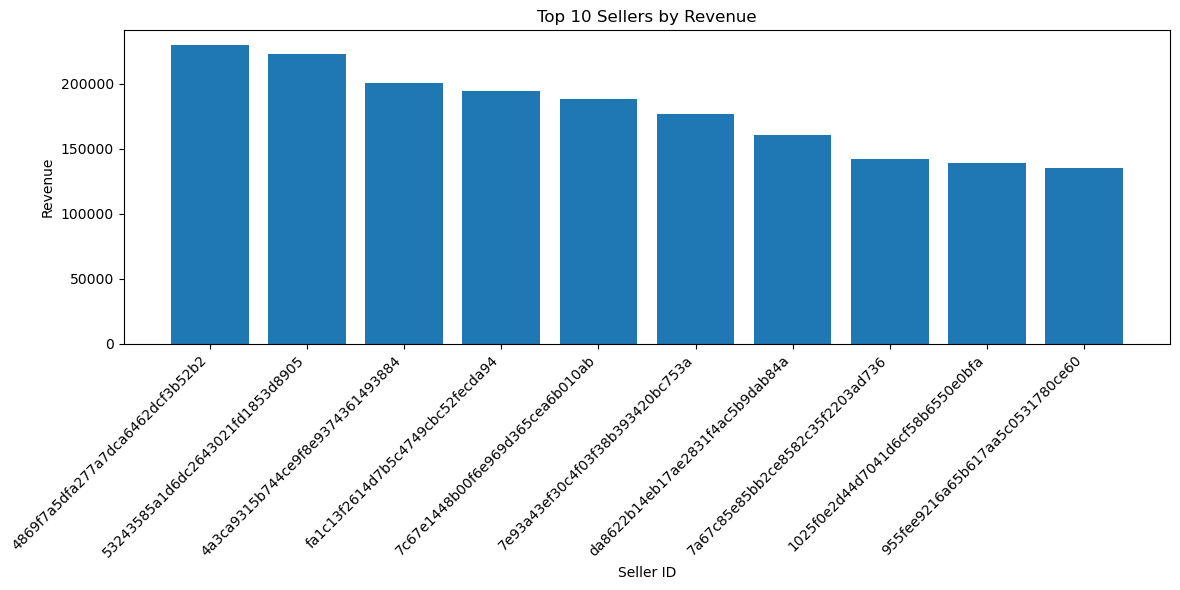

In [24]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_sellers['seller_id'].astype(str),
    top_sellers['total_revenue']
)

plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Seller ID')
plt.ylabel('Revenue')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [25]:
customer_spending = (
    sales_data
    .groupby('customer_id')
    .agg(
        total_spending=('price', 'sum'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)

customer_spending['total_spending'] = customer_spending['total_spending'].round(2)

customer_spending.head()

,customer_id,total_spending,total_orders
0,00012a2ce6f8dcda20d059ce98491703,89.80,1
1,000161a058600d5901f007fab4c27140,54.90,1
2,0001fd6190edaaf884bcaf3d49edf079,179.99,1
3,0002414f95344307404f0ace7a26f1d5,149.90,1
4,000379cdec625522490c315e70c7a9fb,93.00,1


In [26]:
top_customers = (
    customer_spending
    .sort_values('total_spending', ascending=False)
    .head(10)
)

top_customers

,customer_id,total_spending,total_orders
8475,1617b1357756262bfa56ab541c47bc16,13440.0,1
91284,ec5b2ba62e574342386871631fafd3fc,7160.0,1
76948,c6e2731c5b391845f6800c97401a43a9,6735.0,1
94398,f48d464a0baaea338cb25f816991ab1f,6729.0,1
24603,3fd6777bbce08a352fddd04e4a7cc8f6,6499.0,1
2049,05455dfa7cd02f13d132aa7a6a9729c6,5934.6,1
86248,df55c14d1476a9a3467f131269c2477f,4799.0,1
14182,24bbf5fd2f2e1b359ee7de94defc4a15,4690.0,1
86733,e0a2412720e9ea4f26c1ac985f6a7358,4599.9,1
23771,3d979689f636322c62418b6346b1c6d2,4590.0,1


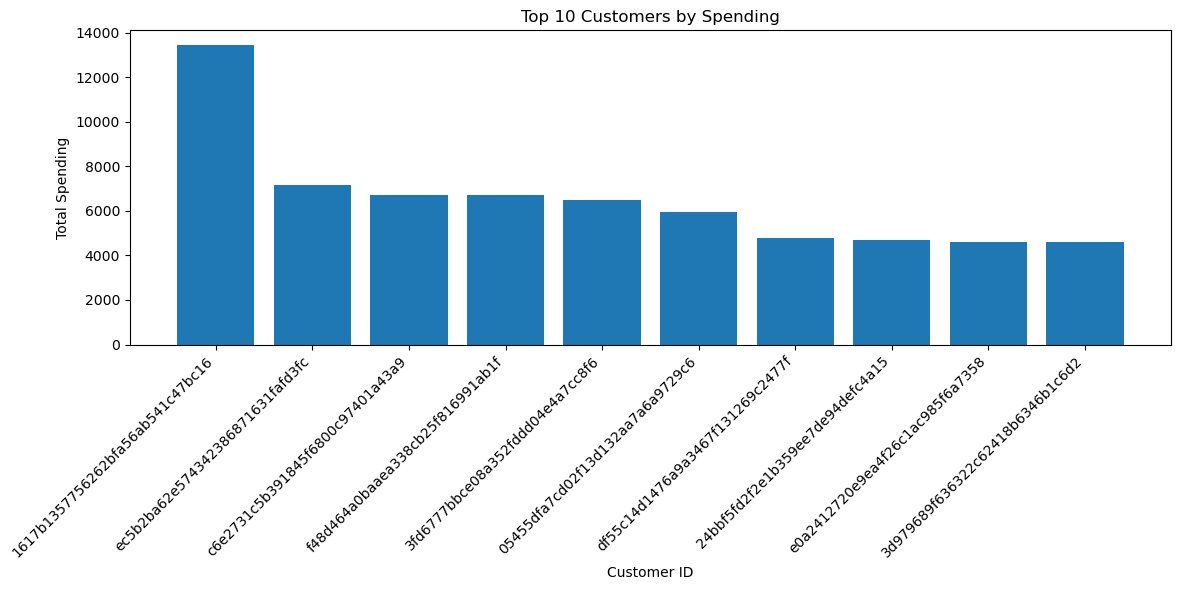

In [27]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_customers['customer_id'].astype(str),
    top_customers['total_spending']
)

plt.title('Top 10 Customers by Spending')
plt.xlabel('Customer ID')
plt.ylabel('Total Spending')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

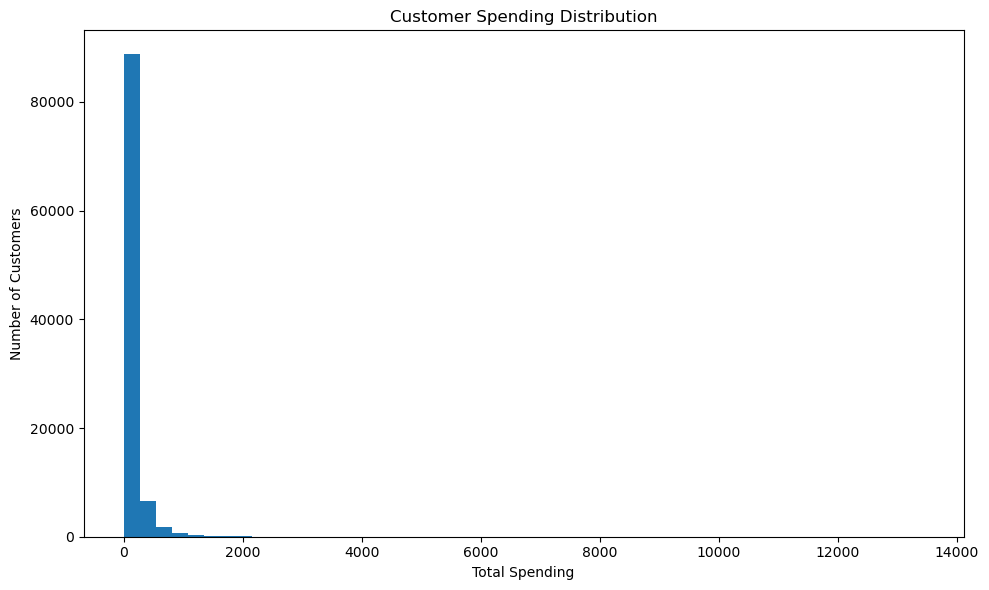

In [28]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_spending['total_spending'],
    bins=50
)

plt.title('Customer Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [29]:
customer_type = customer_spending.copy()

customer_type['customer_type'] = customer_type['total_orders'].apply(
    lambda x: 'Repeat Customer' if x > 1 else 'One-time Customer'
)

customer_type['customer_type'].value_counts()

customer_type
One-time Customer    98666
Name: count, dtype: int64

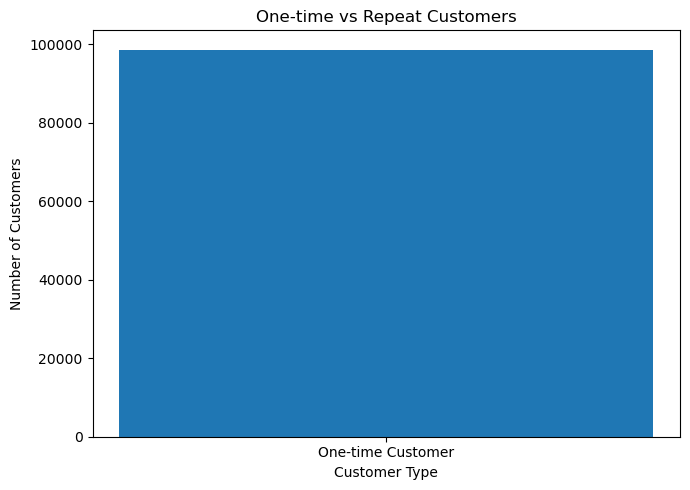

In [30]:
customer_counts = customer_type['customer_type'].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    customer_counts.index,
    customer_counts.values
)

plt.title('One-time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [31]:
category_performance = (
    category_sales
    .groupby('category')
    .agg(
        total_revenue=('price', 'sum'),
        total_items=('price', 'count'),
        average_price=('price', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

category_performance['total_revenue'] = category_performance['total_revenue'].round(2)
category_performance['average_price'] = category_performance['average_price'].round(2)

category_performance.head(10)

,category,total_revenue,total_items,average_price
0,health_beauty,1258681.34,9670,130.16
1,watches_gifts,1205005.68,5991,201.14
2,bed_bath_table,1036988.68,11115,93.30
3,sports_leisure,988048.97,8641,114.34
4,computers_accessories,911954.32,7827,116.51
5,furniture_decor,729762.49,8334,87.56
6,cool_stuff,635290.85,3796,167.36
7,housewares,632248.66,6964,90.79
8,auto,592720.11,4235,139.96
9,garden_tools,485256.46,4347,111.63


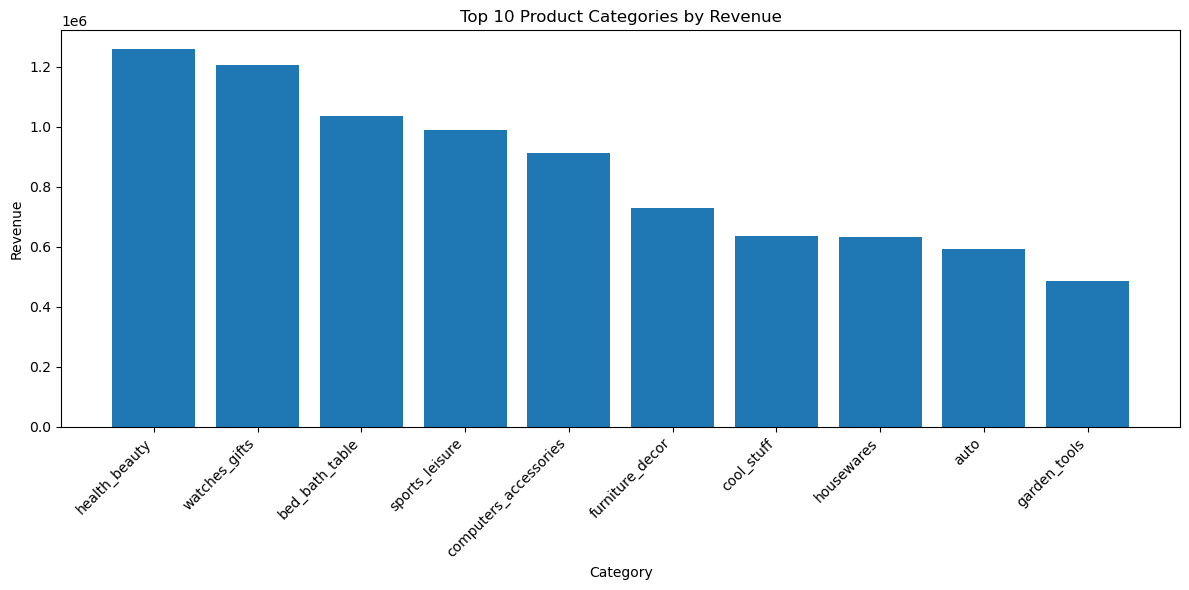

In [32]:
top_categories = category_performance.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_categories['category'],
    top_categories['total_revenue']
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

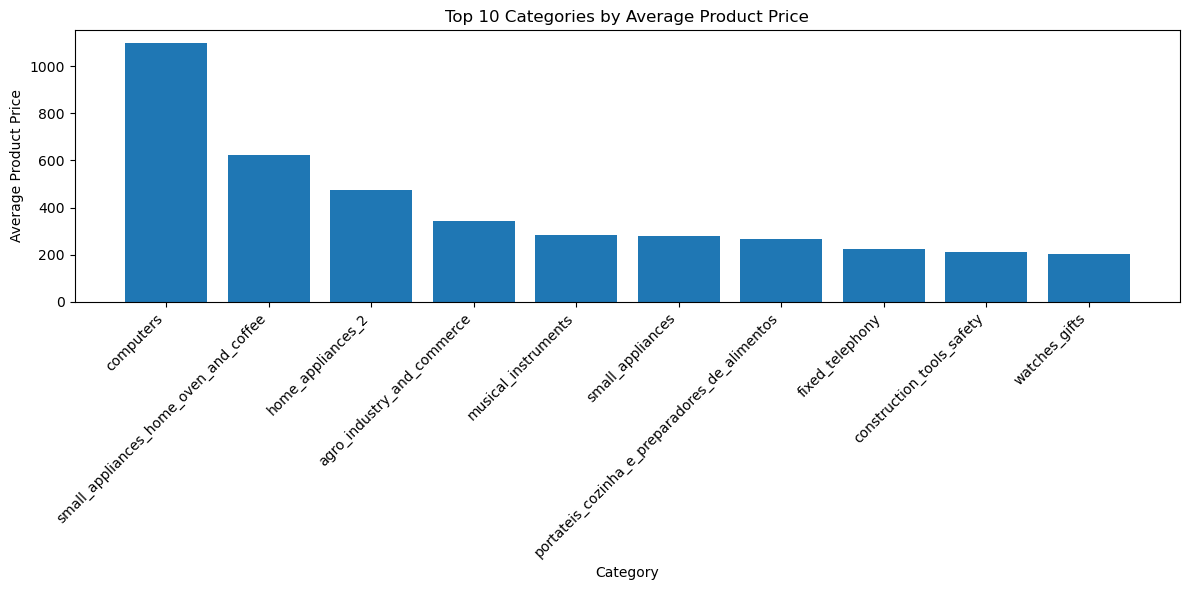

In [33]:
top_price_categories = (
    category_performance
    .sort_values('average_price', ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_price_categories['category'],
    top_price_categories['average_price']
)

plt.title('Top 10 Categories by Average Product Price')
plt.xlabel('Category')
plt.ylabel('Average Product Price')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [34]:
seller_performance = (
    order_items
    .groupby('seller_id')
    .agg(
        total_revenue=('price', 'sum'),
        total_items=('order_id', 'count'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)

seller_performance['average_order_value'] = (
    seller_performance['total_revenue'] /
    seller_performance['total_orders']
)

seller_performance = seller_performance.sort_values(
    'total_revenue',
    ascending=False
)

seller_performance.head(10)

,seller_id,total_revenue,total_items,total_orders,average_order_value
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1156,1132,202.714337
1013,53243585a1d6dc2643021fd1853d8905,222776.05,410,358,622.279469
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1987,1806,111.003832
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,586,585,331.695778
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,1364,982,191.368523
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,340,336,525.094851
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1551,1314,121.945639
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1171,1160,122.194422
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,1428,915,151.878197
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1499,1287,105.028516


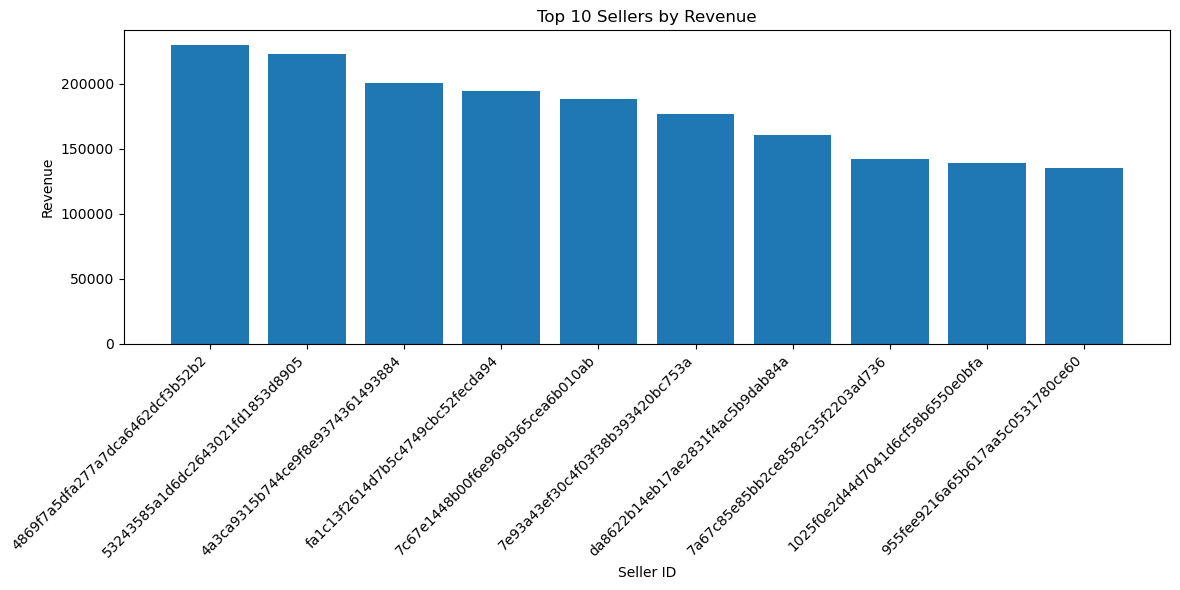

In [35]:
top_sellers = seller_performance.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_sellers['seller_id'].astype(str),
    top_sellers['total_revenue']
)

plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Seller ID')
plt.ylabel('Revenue')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [36]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

In [37]:
orders['delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.days

In [38]:
avg_delivery_days = orders['delivery_days'].mean()

print("Average Delivery Time:", round(avg_delivery_days, 2), "days")

Average Delivery Time: 12.09 days


In [39]:
valid_delivery = (
    orders['order_delivered_customer_date'].notna() &
    orders['order_estimated_delivery_date'].notna()
)

orders['delivery_status'] = 'Unknown'

orders.loc[
    valid_delivery &
    (orders['order_delivered_customer_date'] <=
     orders['order_estimated_delivery_date']),
    'delivery_status'
] = 'On Time'

orders.loc[
    valid_delivery &
    (orders['order_delivered_customer_date'] >
     orders['order_estimated_delivery_date']),
    'delivery_status'
] = 'Delayed'

In [40]:
delivery_counts = orders['delivery_status'].value_counts()

delivery_counts

delivery_status
On Time    88649
Delayed     7827
Unknown     2965
Name: count, dtype: int64

In [41]:
delivery_percentage = (
    orders['delivery_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

delivery_percentage

delivery_status
On Time    89.15
Delayed     7.87
Unknown     2.98
Name: proportion, dtype: float64

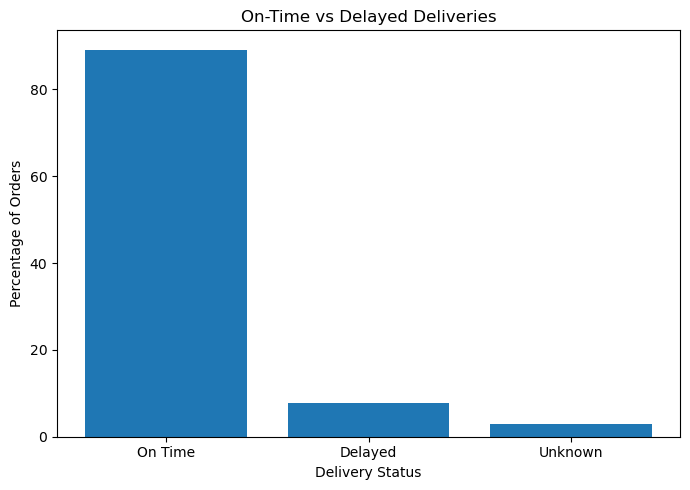

In [42]:
plt.figure(figsize=(7, 5))

plt.bar(
    delivery_percentage.index,
    delivery_percentage.values
)

plt.title('On-Time vs Delayed Deliveries')
plt.xlabel('Delivery Status')
plt.ylabel('Percentage of Orders')

plt.tight_layout()
plt.show()

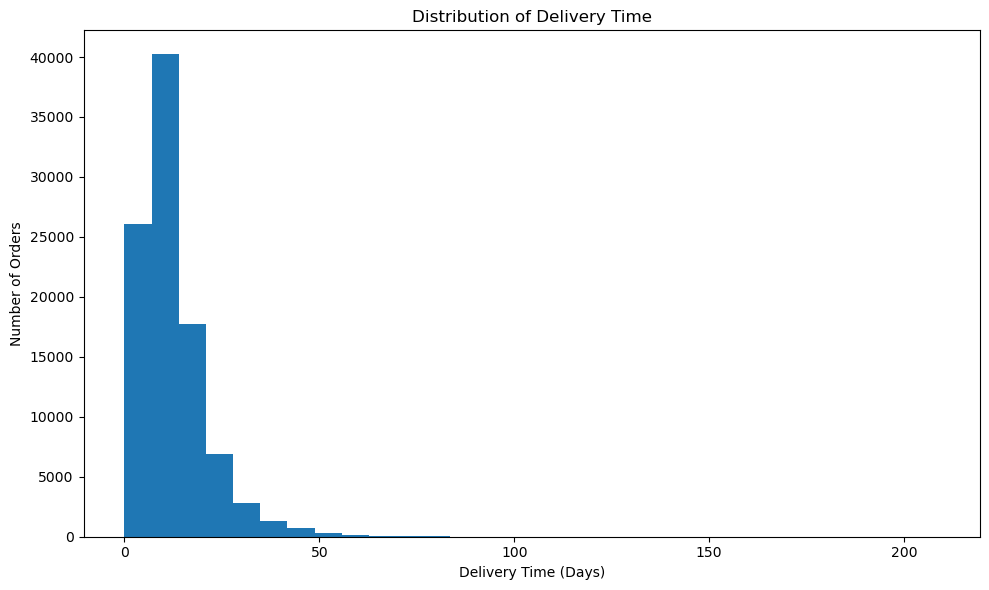

In [43]:
plt.figure(figsize=(10, 6))

plt.hist(
    orders.loc[orders['delivery_days'].notna(), 'delivery_days'],
    bins=30
)

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

In [45]:
reviews = pd.read_csv(
    r"C:\Users\saran\guvi project\cart2insights\data\cleaned\order_reviews_cleaned.csv"
)

print(reviews.shape)

(99224, 7)


In [46]:
delivery_reviews = reviews.merge(
    orders[['order_id', 'delivery_status']],
    on='order_id',
    how='inner'
)

delivery_reviews = delivery_reviews[
    delivery_reviews['delivery_status'].isin(['On Time', 'Delayed'])
].copy()

delivery_reviews['review_score'] = pd.to_numeric(
    delivery_reviews['review_score'],
    errors='coerce'
)

review_by_delivery = (
    delivery_reviews
    .groupby('delivery_status')['review_score']
    .mean()
    .round(2)
)

review_by_delivery

delivery_status
Delayed    2.57
On Time    4.29
Name: review_score, dtype: float64

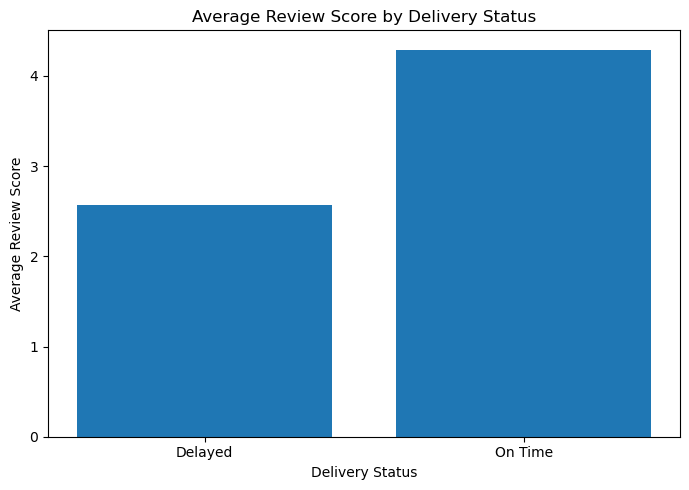

In [47]:
plt.figure(figsize=(7, 5))

plt.bar(
    review_by_delivery.index,
    review_by_delivery.values
)

plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')

plt.tight_layout()
plt.show()

In [48]:
review_scores = (
    reviews['review_score']
    .value_counts()
    .sort_index()
)

review_scores

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

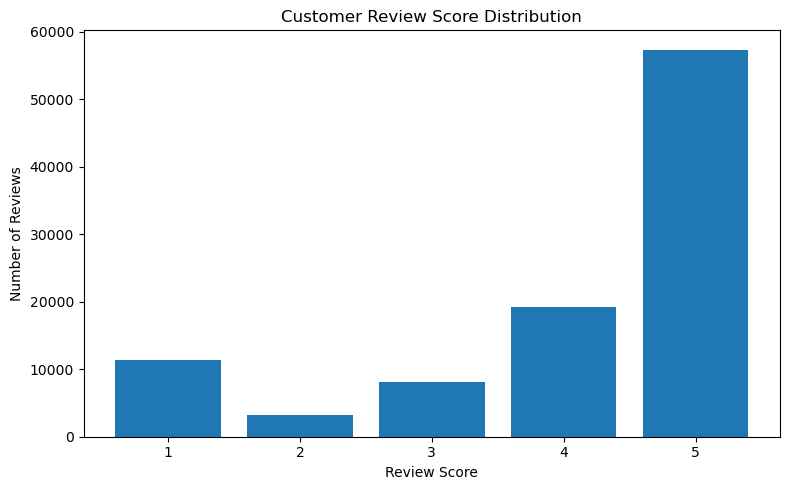

In [49]:
plt.figure(figsize=(8, 5))

plt.bar(
    review_scores.index.astype(str),
    review_scores.values
)

plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

In [50]:
average_review = reviews['review_score'].mean()

print(
    "Average Customer Review Score:",
    round(average_review, 2)
)

Average Customer Review Score: 4.09


In [51]:
review_category = reviews.merge(
    orders[['order_id', 'customer_id']],
    on='order_id',
    how='inner'
)

review_category = review_category.merge(
    order_items[['order_id', 'product_id']],
    on='order_id',
    how='left'
)

review_category = review_category.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

review_category = review_category.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

In [52]:
review_category['category'] = (
    review_category['product_category_name_english']
    .fillna(review_category['product_category_name'])
    .fillna('unknown')
)

In [53]:
category_reviews = (
    review_category
    .groupby('category')['review_score']
    .agg(['count', 'mean'])
    .sort_values('mean', ascending=False)
    .reset_index()
)

category_reviews['mean'] = category_reviews['mean'].round(2)

category_reviews.head(10)

,category,count,mean
0,cds_dvds_musicals,14,4.64
1,fashion_childrens_clothes,8,4.50
2,books_general_interest,549,4.45
3,costruction_tools_tools,99,4.44
4,flowers,31,4.42
5,books_imported,60,4.40
6,books_technical,266,4.37
7,food_drink,279,4.32
8,luggage_accessories,1088,4.32
9,small_appliances_home_oven_and_coffee,76,4.30


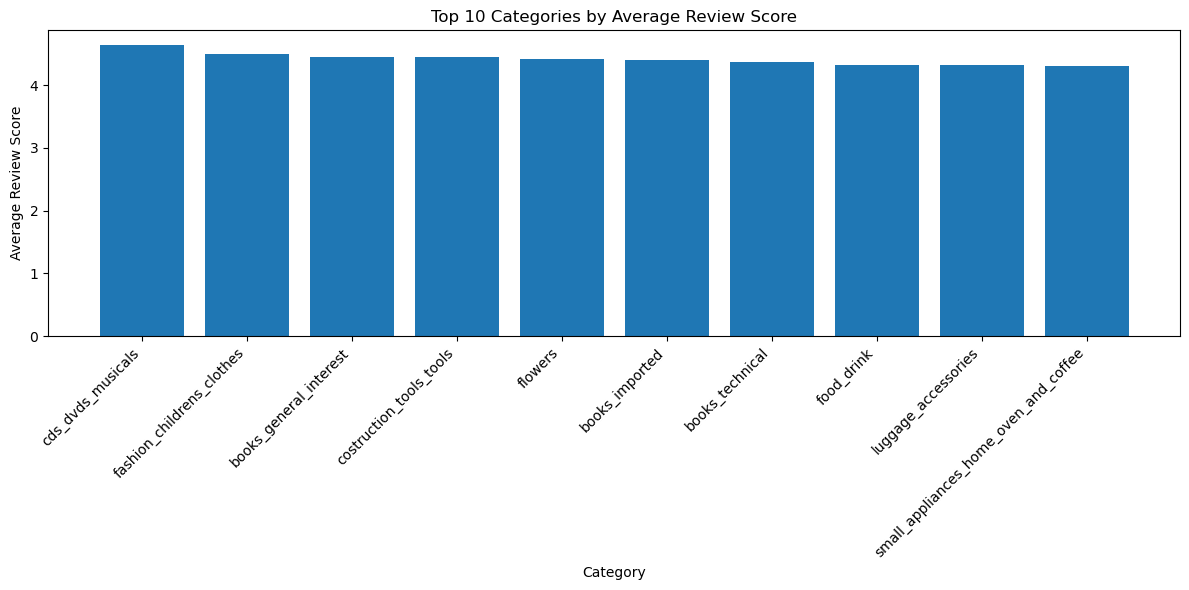

In [54]:
top_review_categories = category_reviews.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_review_categories['category'],
    top_review_categories['mean']
)

plt.title('Top 10 Categories by Average Review Score')
plt.xlabel('Category')
plt.ylabel('Average Review Score')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [55]:
# Customer Experience Analysis

review_scores = (
    reviews['review_score']
    .value_counts()
    .sort_index()
)

print(review_scores)

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


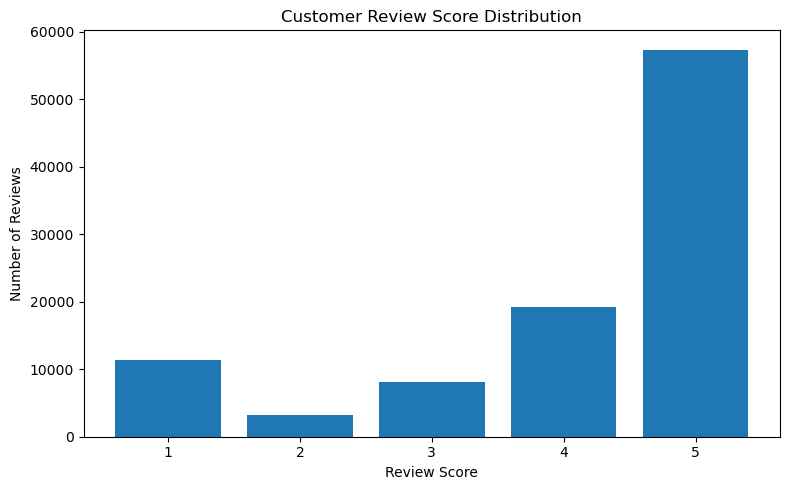

In [56]:
plt.figure(figsize=(8, 5))

plt.bar(
    review_scores.index.astype(str),
    review_scores.values
)

plt.title('Customer Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

In [57]:
average_review = reviews['review_score'].mean()

print("Average Customer Review Score:", round(average_review, 2))

Average Customer Review Score: 4.09


In [58]:
delivery_reviews = reviews.merge(
    orders[['order_id', 'delivery_status']],
    on='order_id',
    how='inner'
)

delivery_reviews = delivery_reviews[
    delivery_reviews['delivery_status'].isin(['On Time', 'Delayed'])
].copy()

delivery_reviews['review_score'] = pd.to_numeric(
    delivery_reviews['review_score'],
    errors='coerce'
)

review_by_delivery = (
    delivery_reviews
    .groupby('delivery_status')['review_score']
    .mean()
    .round(2)
)

print(review_by_delivery)

delivery_status
Delayed    2.57
On Time    4.29
Name: review_score, dtype: float64


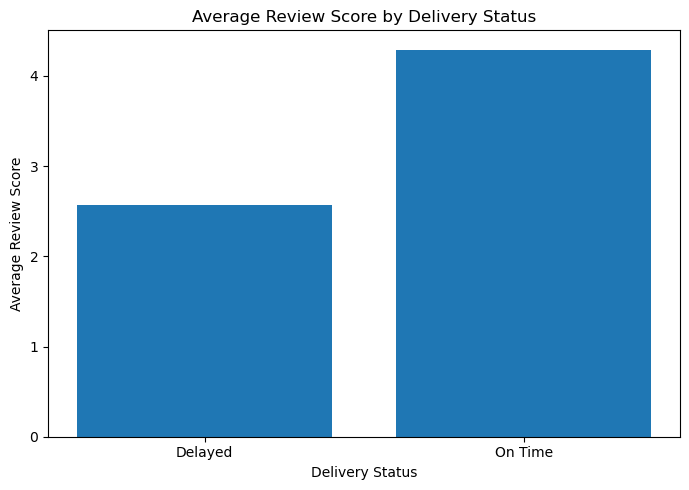

In [59]:
plt.figure(figsize=(7, 5))

plt.bar(
    review_by_delivery.index,
    review_by_delivery.values
)

plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')

plt.tight_layout()
plt.show()

In [60]:
import os

dashboard_path = r"C:\Users\saran\guvi project\cart2insights\data\dashboard"

os.makedirs(dashboard_path, exist_ok=True)

print("Dashboard folder ready")

Dashboard folder ready


In [61]:
monthly_revenue.to_csv(
    f"{dashboard_path}/monthly_revenue.csv",
    index=False
)

category_performance.to_csv(
    f"{dashboard_path}/category_performance.csv",
    index=False
)

product_revenue.to_csv(
    f"{dashboard_path}/product_revenue.csv",
    index=False
)

seller_performance.to_csv(
    f"{dashboard_path}/seller_performance.csv",
    index=False
)

customer_spending.to_csv(
    f"{dashboard_path}/customer_spending.csv",
    index=False
)

category_reviews.to_csv(
    f"{dashboard_path}/category_reviews.csv",
    index=False
)

review_by_delivery.to_csv(
    f"{dashboard_path}/review_by_delivery.csv"
)

print("All dashboard datasets saved successfully.")

All dashboard datasets saved successfully.


In [62]:
os.listdir(dashboard_path)

['category_performance.csv',
 'category_reviews.csv',
 'customer_spending.csv',
 'monthly_revenue.csv',
 'product_revenue.csv',
 'review_by_delivery.csv',
 'seller_performance.csv']

In [10]:
delivery_summary = (
    orders[orders["delivery_status"].notna()]
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "count"),
        average_delivery_days=("delivery_days", "mean")
    )
    .reset_index()
)

delivery_summary["percentage"] = (
    delivery_summary["orders"]
    / delivery_summary["orders"].sum()
    * 100
)

delivery_summary

,delivery_status,orders,average_delivery_days,percentage
0,Delayed,7827,31.057749,8.112899
1,On Time,88649,10.419745,91.887101


In [3]:
# Convert date columns
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [4]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [5]:
orders["delivery_status"] = None

valid_delivery = (
    orders["order_delivered_customer_date"].notna()
    &
    orders["order_estimated_delivery_date"].notna()
)

orders.loc[
    valid_delivery
    &
    (
        orders["order_delivered_customer_date"]
        <= orders["order_estimated_delivery_date"]
    ),
    "delivery_status"
] = "On Time"

orders.loc[
    valid_delivery
    &
    (
        orders["order_delivered_customer_date"]
        > orders["order_estimated_delivery_date"]
    ),
    "delivery_status"
] = "Delayed"

In [6]:
orders["delivery_status"].value_counts(dropna=False)

delivery_status
On Time    88649
Delayed     7827
None        2965
Name: count, dtype: int64

In [7]:
delivery_summary = (
    orders[orders["delivery_status"].notna()]
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "count"),
        average_delivery_days=("delivery_days", "mean")
    )
    .reset_index()
)

delivery_summary["percentage"] = (
    delivery_summary["orders"]
    / delivery_summary["orders"].sum()
    * 100
)

delivery_summary

,delivery_status,orders,average_delivery_days,percentage
0,Delayed,7827,31.057749,8.112899
1,On Time,88649,10.419745,91.887101


In [8]:
orders["delivery_status"].value_counts(dropna=False)

delivery_status
On Time    88649
Delayed     7827
None        2965
Name: count, dtype: int64

In [9]:
delivery_summary.to_csv(
    r"C:\Users\saran\guvi project\cart2insights\data\dashboard\delivery_summary.csv",
    index=False
)

print("Delivery summary saved successfully!")

Delivery summary saved successfully!
